# More Matplotlib

A figure is how you actually *see* your data — and how you communicate it to everyone else. Matplotlib is the dominant plotting library in Python, and learning to drive it deliberately (rather than by trial and error) pays off every time you plot a temperature record, a map, or a scatter of measurements. In the previous notebook we made quick plots while learning NumPy; here we slow down to understand how Matplotlib is built.

The key idea is the **Figure / Axes** model: a *Figure* is the whole canvas, and each *Axes* is a single plot living on it. Once that clicks, everything else — subplots, labels, colors, 2-D fields, vector fields — follows from it. We'll work through line plots and their styling, then the main ways to visualize 2-D data (`imshow`, `pcolormesh`, `contour`, `quiver`, `streamplot`).

:::{admonition} Working through this notebook
:class: tip
This page is a Jupyter notebook. **Download it** using the ⬇ button in the top-right of the page (or copy-paste the cells into a fresh notebook), open it in your environment (JupyterLab on LEAP or Colab), and step through the cells. When you reach a **Try it** admonition, experiment in your own cells before moving on.
:::

:::{admonition} In-class assignment — 10 points
:class: note
The **"Try it"** exercises in this notebook are part of your in-class assignment for this section. Complete them in your own copy of the notebook, push it to your week folder, and post the notebook link on the matching **Courseworks** assignment. (One 10-point assignment covers all the lecture notebooks in this section.)
:::

In [1]:
from matplotlib import pyplot as plt
%matplotlib inline

## Figure and Axes

The *figure* is the highest level of organization of matplotlib objects. If we want, we can create a figure explicitly.

In [2]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

In [3]:
fig = plt.figure(figsize=(13, 5))

<Figure size 1300x500 with 0 Axes>

To draw anything, the figure needs an **axes** inside it. We add one with `fig.add_axes([left, bottom, width, height])` — the four numbers are in *figure coordinates* (0 to 1, where 0 is the left/bottom edge of the figure and 1 is the right/top). `[0, 0, 1, 1]` makes the axes fill the entire figure:

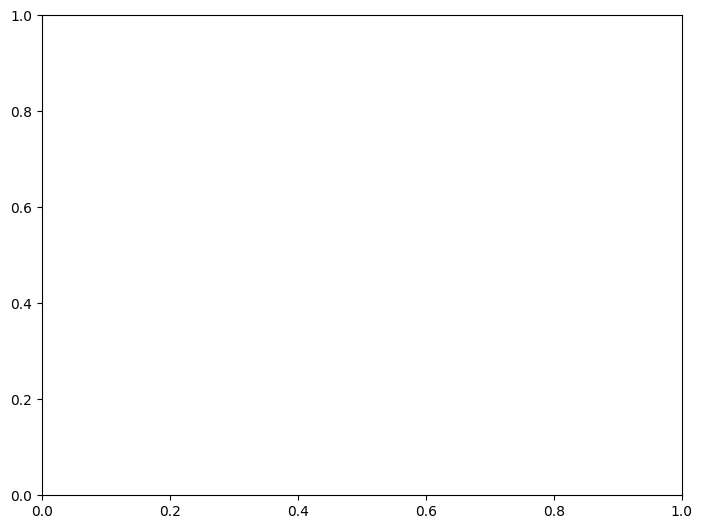

In [4]:
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])

With a different bbox we can make the axes smaller — `[0, 0, 0.5, 1]` puts the axes on the left half of the figure:

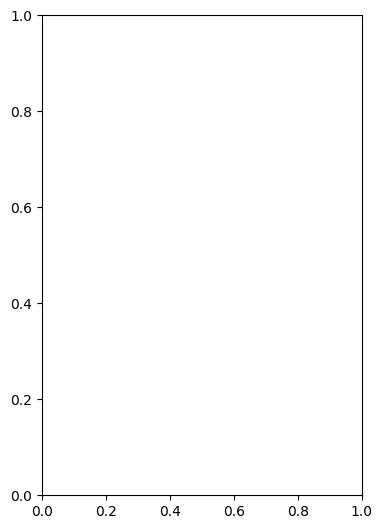

In [5]:
fig = plt.figure()
ax = fig.add_axes([0, 0, 0.5, 1])

We can add **multiple** axes to one figure by calling `add_axes` with different bboxes:

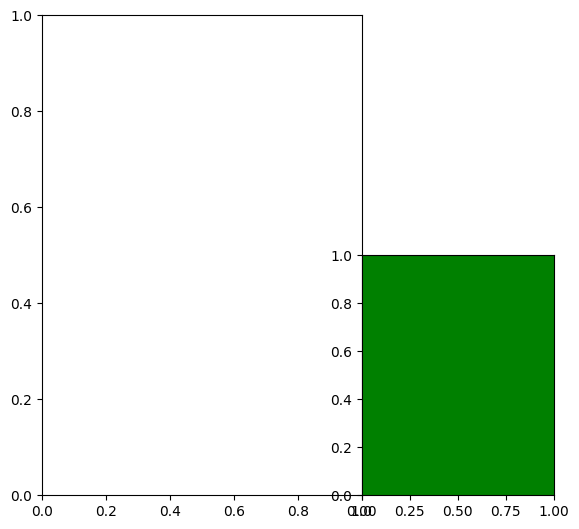

In [6]:
fig = plt.figure()
ax1 = fig.add_axes([0, 0, 0.5, 1])
ax2 = fig.add_axes([0.5, 0, 0.3, 0.5], facecolor='g')

### Subplots

`subplots` is the standard way to create multiple axes in a regular grid. Pass `nrows` and `ncols` to lay out the grid — matplotlib returns a single `Axes` if there's only one, or a NumPy array of `Axes` if there are several.

Calling `subplots` on a figure carves it up into a regular grid of axes — here, 2 rows × 3 columns:

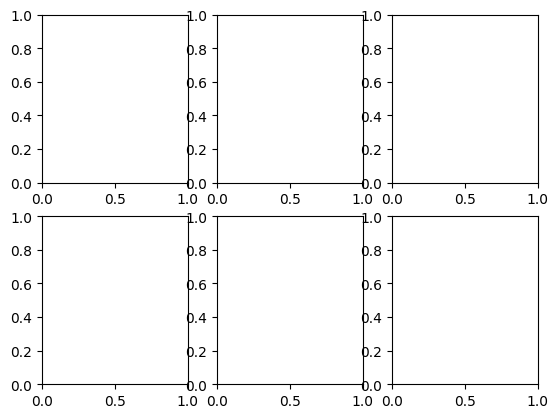

In [7]:
fig = plt.figure()
axes = fig.subplots(nrows=2, ncols=3)

If we make the figure smaller, the axes labels will overlap — matplotlib doesn't auto-resize them:

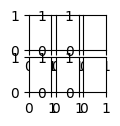

In [8]:
fig = plt.figure(figsize=(1, 1))
axes = fig.subplots(nrows=2, ncols=3)

Notice that `subplots(nrows=2, ncols=3)` returned a **2D array** of `Axes` objects — we can inspect it directly, or index into it like any NumPy array:

In [9]:
axes

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

In [10]:
axes[0,0]

<Axes: >

There is a shorthand for doing this all at once.

:::{tip}
**This is our recommended way to create new figures!** From here on, most cells will use the `fig, ax = plt.subplots(...)` pattern.
:::

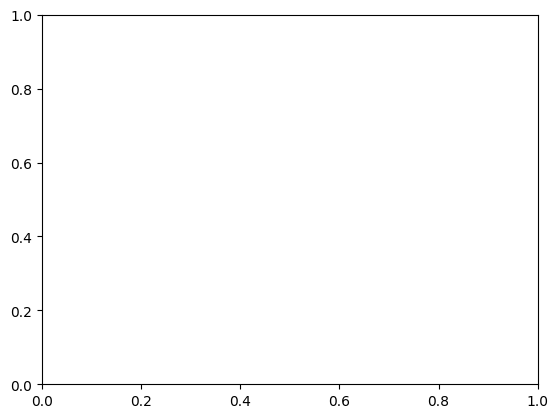

In [11]:
fig, ax = plt.subplots()

In [12]:
ax

<Axes: >

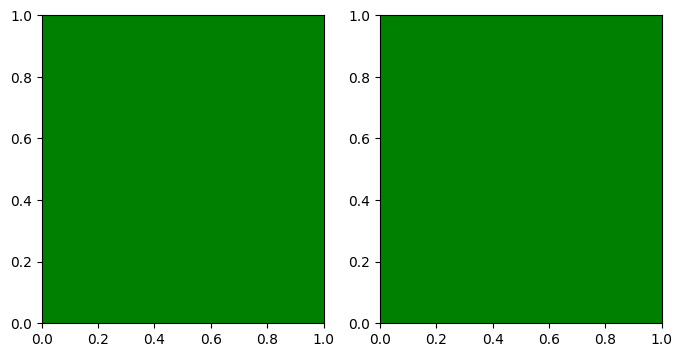

In [13]:
fig, axes = plt.subplots(ncols=2, figsize=(8, 4), subplot_kw={'facecolor': 'g'})

In [14]:
axes

array([<Axes: >, <Axes: >], dtype=object)

:::{admonition} Try it
:class: tip
Use `plt.subplots(nrows=2, ncols=2, figsize=(8, 8))` to create a 2×2 grid of axes. Print the shape of the returned `axes` object (it's a 2D NumPy array of `Axes`), and access the top-right axes with `axes[0, 1]`. Then change `figsize` to `(4, 4)` and see how the figure size changes.
:::

axes shape: (2, 2)
top-right axes: Axes(0.547727,0.53;0.352273x0.35)


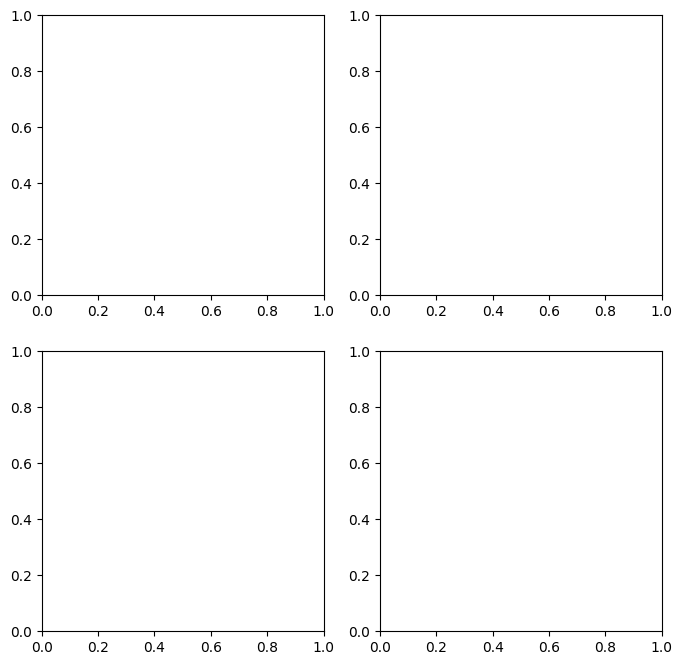

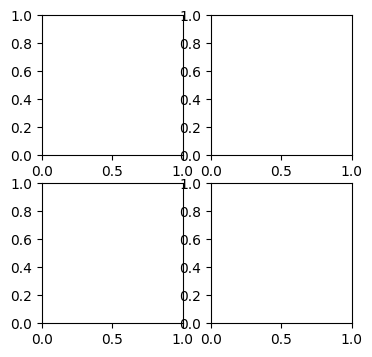

In [15]:
# --- Try it: 2x2 grid of axes ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
print("axes shape:", axes.shape)          # (2, 2) -- a 2D array of Axes
print("top-right axes:", axes[0, 1])
plt.show()

# Same layout, smaller figure:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(4, 4))
plt.show()

## Drawing into Axes

All plots are drawn into a specific axes. Matplotlib supports two styles for this — the implicit `plt.plot(...)` style (which uses the most recently created axes), and the **explicit object-oriented style** (`ax.plot(...)`) where you call methods on the axes directly. The OO style is much clearer once you have more than one axes on a figure, and it's what we recommend throughout the rest of this course. (See the [matplotlib coding style guide](https://matplotlib.org/stable/users/explain/figure/api_interfaces.html) for more.)

Let's create some data we'll plot throughout the rest of this notebook — a smooth cosine and a higher-frequency sine on the same x-range:

In [16]:
import numpy as np
x = np.linspace(-np.pi, np.pi, 100)
y = np.cos(x)
z = np.sin(6*x)

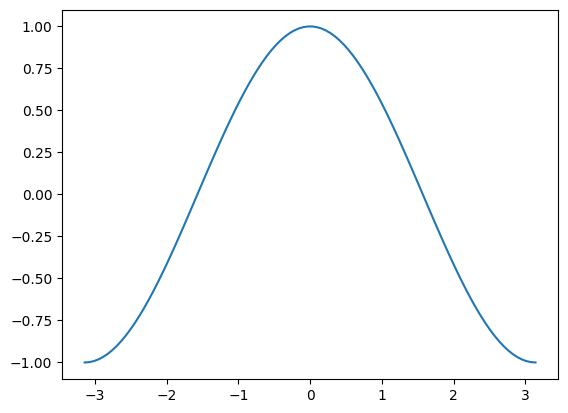

In [17]:
plt.plot(x,y)

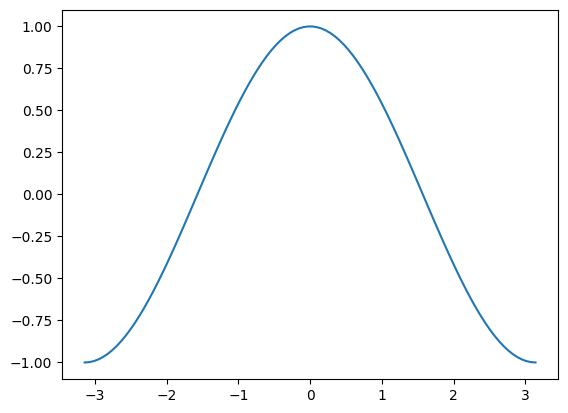

In [18]:
fig, ax = plt.subplots()
plt.plot(x,y)

In [19]:
ax

<Axes: >

In [20]:
ax.plot(x, y)

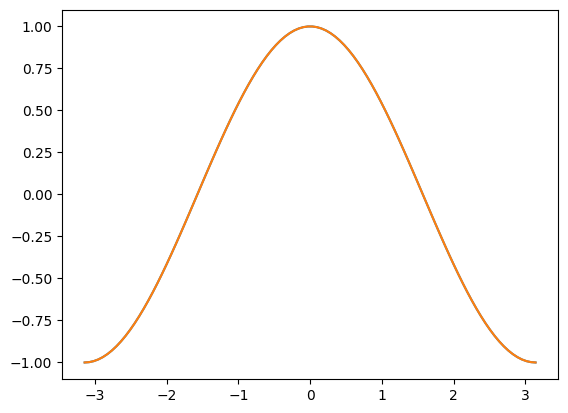

In [21]:
fig

This does the same thing as

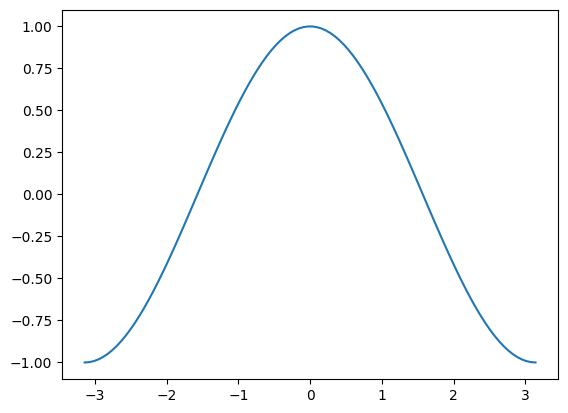

In [22]:
plt.plot(x, y)

This starts to matter when we have multiple axes to worry about.

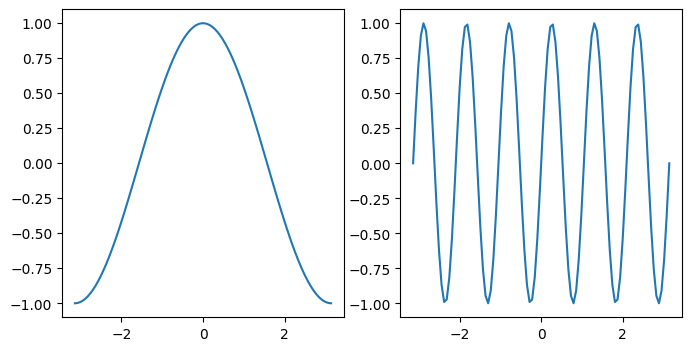

In [23]:
fig, axes = plt.subplots(figsize=(8, 4), ncols=2)
ax0, ax1 = axes
ax0.plot(x, y)
ax1.plot(x, z)

:::{admonition} Try it
:class: tip
Create a figure with two side-by-side axes (`fig, axes = plt.subplots(ncols=2, figsize=(8, 4))`). Plot `np.sin(x)` on the left axes and `np.cos(x)` on the right, using the explicit `axes[0].plot(...)` / `axes[1].plot(...)` pattern.
:::

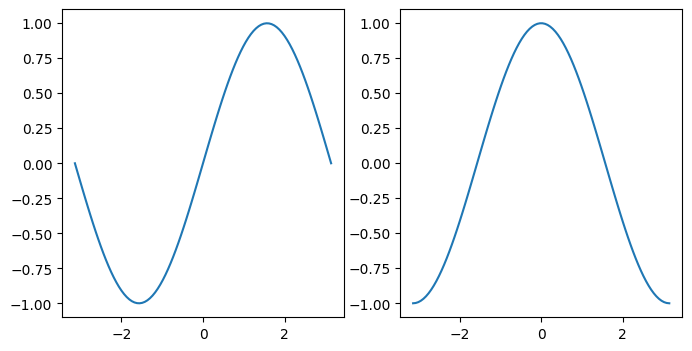

In [24]:
# --- Try it: sin on the left, cos on the right ---
fig, axes = plt.subplots(ncols=2, figsize=(8, 4))
axes[0].plot(x, np.sin(x))
axes[1].plot(x, np.cos(x))
plt.show()

## Labeling Plots

A plot without labels is hard to interpret. Each `Axes` object has `set_xlabel`, `set_ylabel`, and `set_title` methods that take a string. When axes have their own labels and titles, they can crowd each other on the figure — `plt.tight_layout()` fixes the spacing automatically.

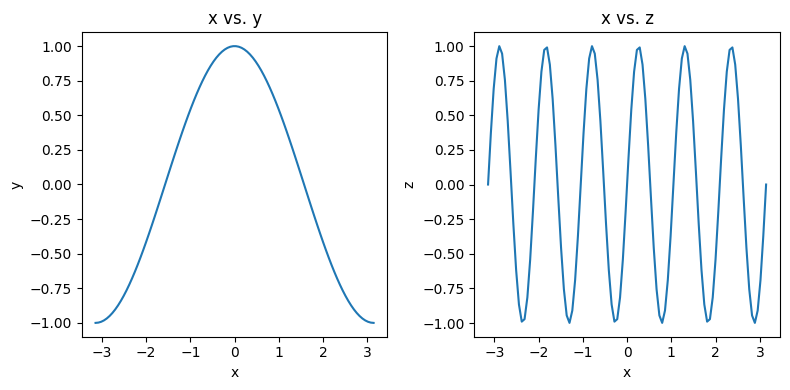

In [25]:
fig, axes = plt.subplots(figsize=(8, 4), ncols=2)
ax0, ax1 = axes

ax0.plot(x, y)
ax0.set_xlabel('x')
ax0.set_ylabel('y')
ax0.set_title('x vs. y')

ax1.plot(x, z)
ax1.set_xlabel('x')
ax1.set_ylabel('z')
ax1.set_title('x vs. z')

# squeeze everything in
plt.tight_layout()

:::{admonition} Try it
:class: tip
Take the two-axes figure from the previous Try-it. Add x/y labels and a title to each axes, then call `plt.tight_layout()` so the labels don't get clipped when the figure is rendered.
:::

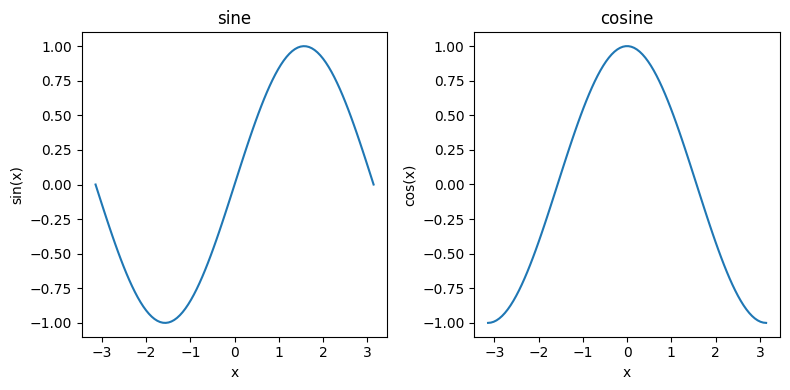

In [26]:
# --- Try it: add labels + titles, then tight_layout ---
fig, axes = plt.subplots(ncols=2, figsize=(8, 4))
axes[0].plot(x, np.sin(x))
axes[0].set_xlabel("x"); axes[0].set_ylabel("sin(x)"); axes[0].set_title("sine")
axes[1].plot(x, np.cos(x))
axes[1].set_xlabel("x"); axes[1].set_ylabel("cos(x)"); axes[1].set_title("cosine")
plt.tight_layout()
plt.show()

## Customizing Line Plots

Once you have a basic plot, you'll usually want to control its appearance: which color the line is, whether it's solid or dashed, whether to mark each data point, and how the axes themselves are styled. The sub-sections below walk through the main knobs.

There are several ways to plot two (or more) datasets on the same axes. The first style passes alternating `x, y` pairs to a single `plot` call:

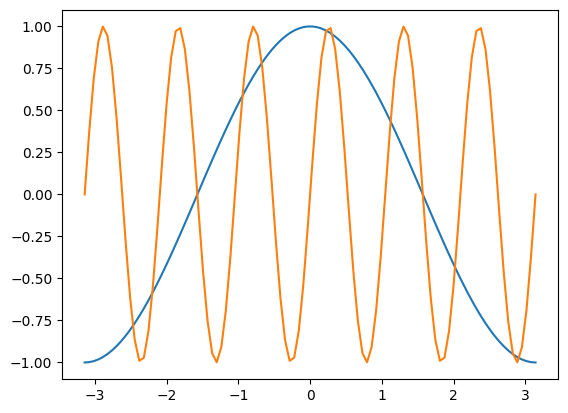

In [27]:
fig, ax = plt.subplots()
ax.plot(x, y, x, z)

The second style calls `plot` separately for each dataset. The result is the same — matplotlib automatically assigns a different color to each line from a default cycle (more on that below):

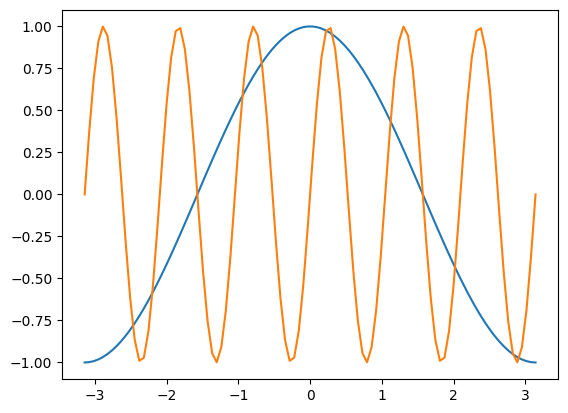

In [28]:
fig, ax = plt.subplots()
ax.plot(x, y)
ax.plot(x, z)

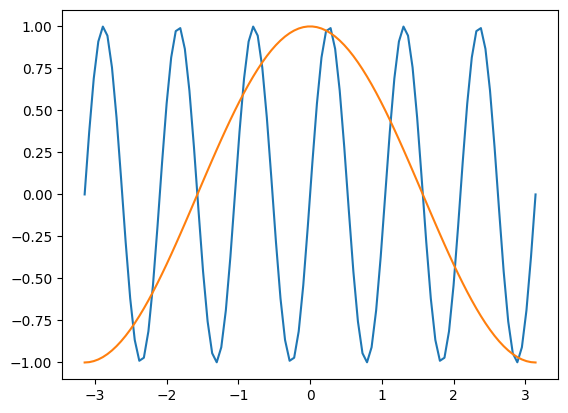

In [29]:
fig, ax = plt.subplots()
ax.plot(x, z)
ax.plot(x, y)


It's simple to switch axes

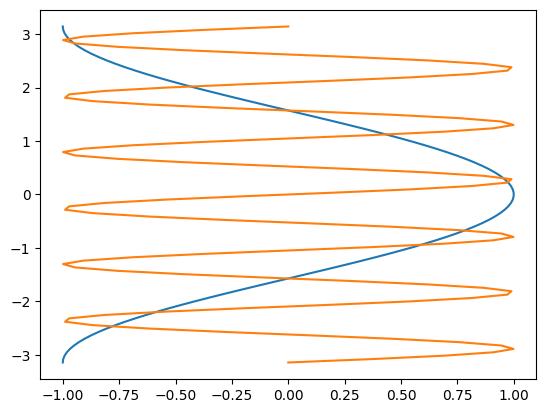

In [30]:
fig, ax = plt.subplots()
ax.plot(y, x, z, x)

A "parametric" graph:

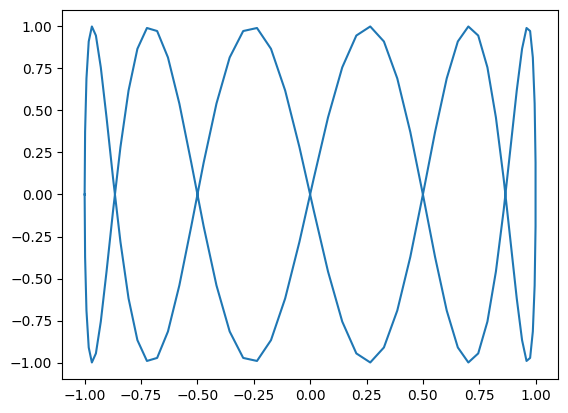

In [31]:
fig, ax = plt.subplots()
ax.plot(y, z)

### Line Styles

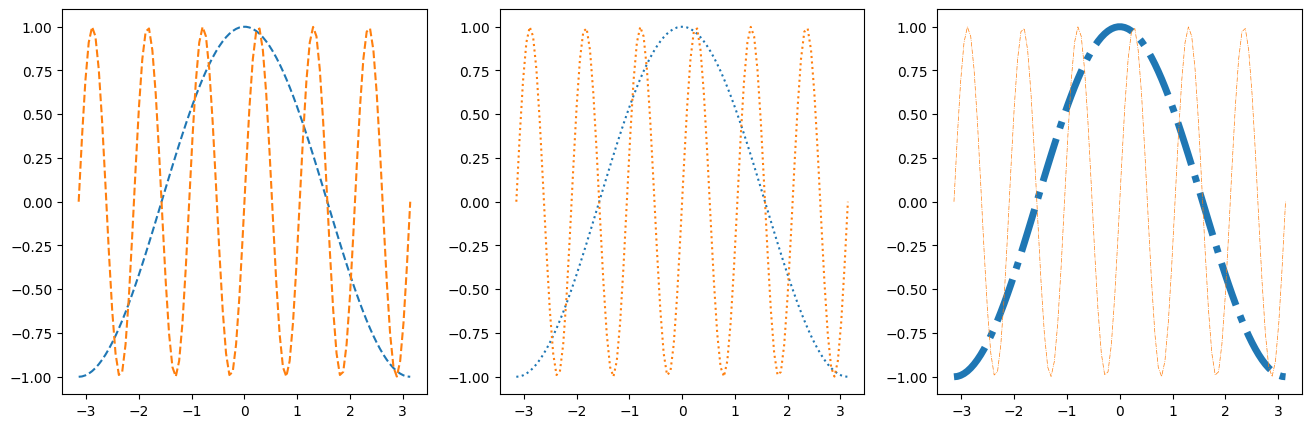

In [32]:
fig, axes = plt.subplots(figsize=(16, 5), ncols=3)
axes[0].plot(x, y, linestyle='dashed')
axes[0].plot(x, z, linestyle='--')

axes[1].plot(x, y, linestyle='dotted')
axes[1].plot(x, z, linestyle=':')

axes[2].plot(x, y, linestyle='dashdot', linewidth=5)
axes[2].plot(x, z, linestyle='-.', linewidth=0.5)


### Colors

As described in the [colors documentation](https://matplotlib.org/2.0.2/api/colors_api.html), there are some special codes for commonly used colors:

- b: blue
- g: green
- r: red
- c: cyan
- m: magenta
- y: yellow
- k: black
- w: white

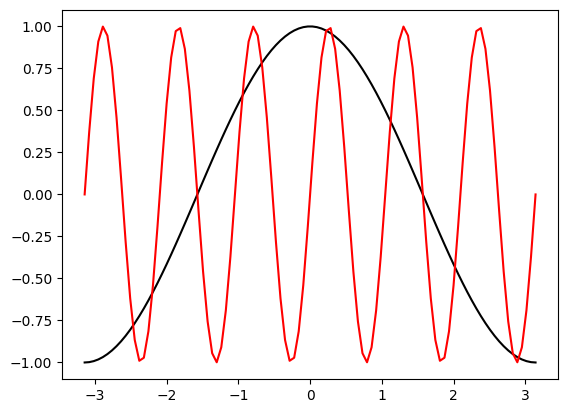

In [33]:
fig, ax = plt.subplots()
ax.plot(x, y, color='k')
ax.plot(x, z, color='r')

Other ways to specify colors:

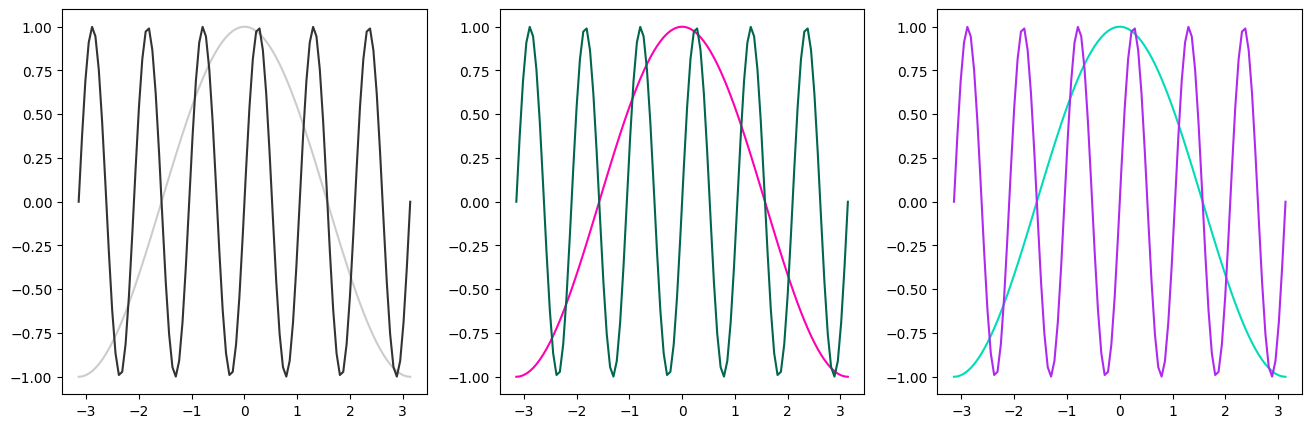

In [34]:
fig, axes = plt.subplots(figsize=(16, 5), ncols=3)

# grayscale
axes[0].plot(x, y, color='0.8')
axes[0].plot(x, z, color='0.2')

# RGB tuple
axes[1].plot(x, y, color=(1, 0, 0.7))
axes[1].plot(x, z, color=(0, 0.4, 0.3))

# HTML hex code
axes[2].plot(x, y, color='#00dcba')
axes[2].plot(x, z, color='#b029ee')

There is a default color cycle built into matplotlib.

You can inspect the default cycle directly. It's stored in matplotlib's runtime config (`rcParams`):

In [35]:
plt.rcParams['axes.prop_cycle']

'#1f77b4'
'#ff7f0e'
'#2ca02c'
'#d62728'
'#9467bd'
'#8c564b'
'#e377c2'
'#7f7f7f'
'#bcbd22'
'#17becf'


If you call `plot` more times than there are colors in the cycle, matplotlib **wraps around** — colors start repeating:

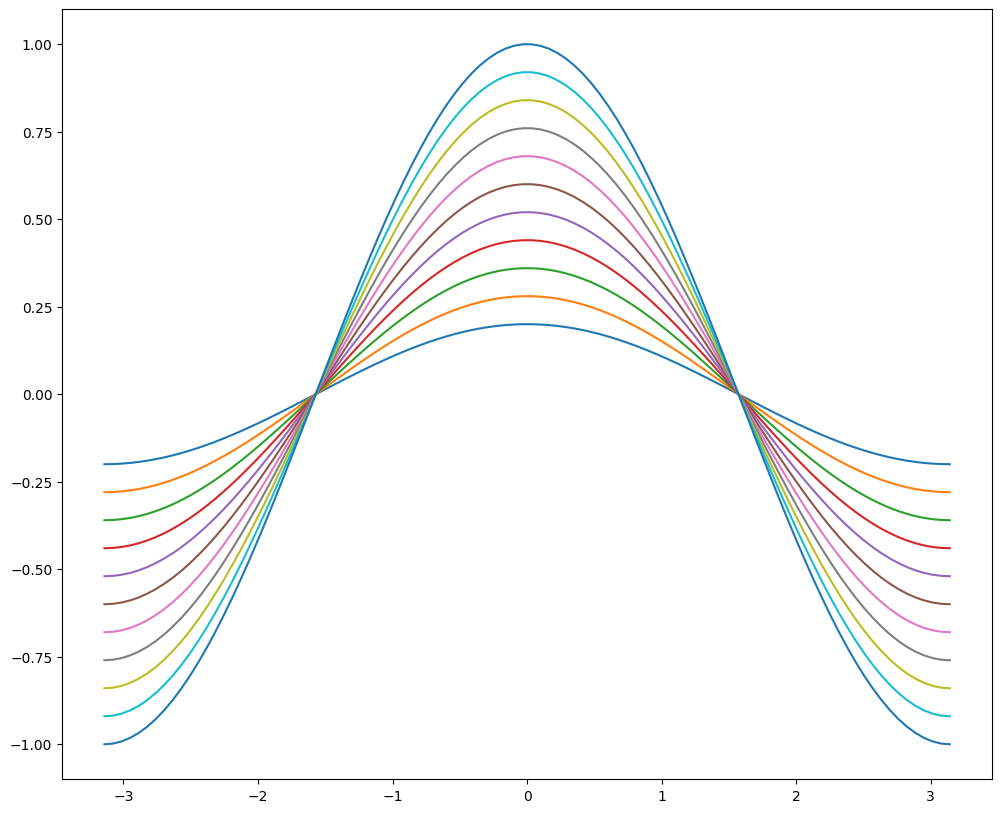

In [36]:
fig, ax = plt.subplots(figsize=(12, 10))
for factor in np.linspace(0.2, 1, 11):
    ax.plot(x, factor*y)

### Markers

There are [lots of different markers](https://matplotlib.org/api/markers_api.html) availabile in matplotlib!

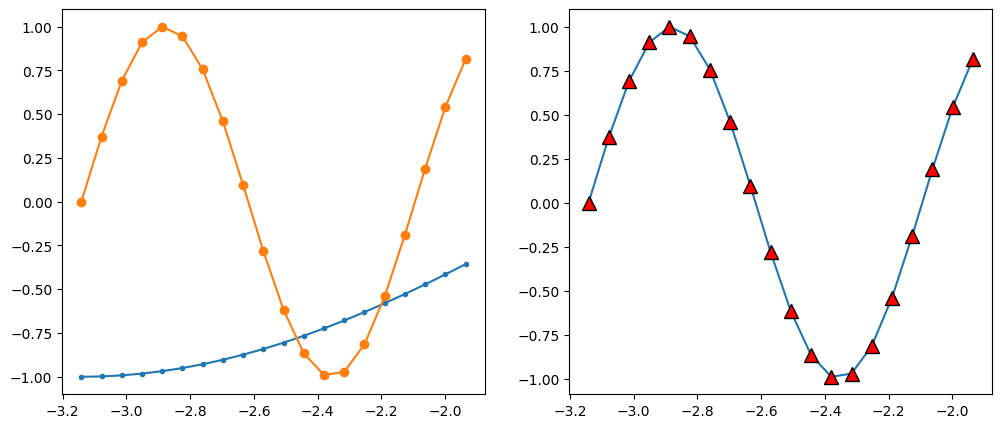

In [37]:
fig, axes = plt.subplots(figsize=(12, 5), ncols=2)

axes[0].plot(x[:20], y[:20], marker='.')
axes[0].plot(x[:20], z[:20], marker='o')

axes[1].plot(x[:20], z[:20], marker='^',
             markersize=10, markerfacecolor='r',
             markeredgecolor='k')

### Label, Ticks, and Gridlines

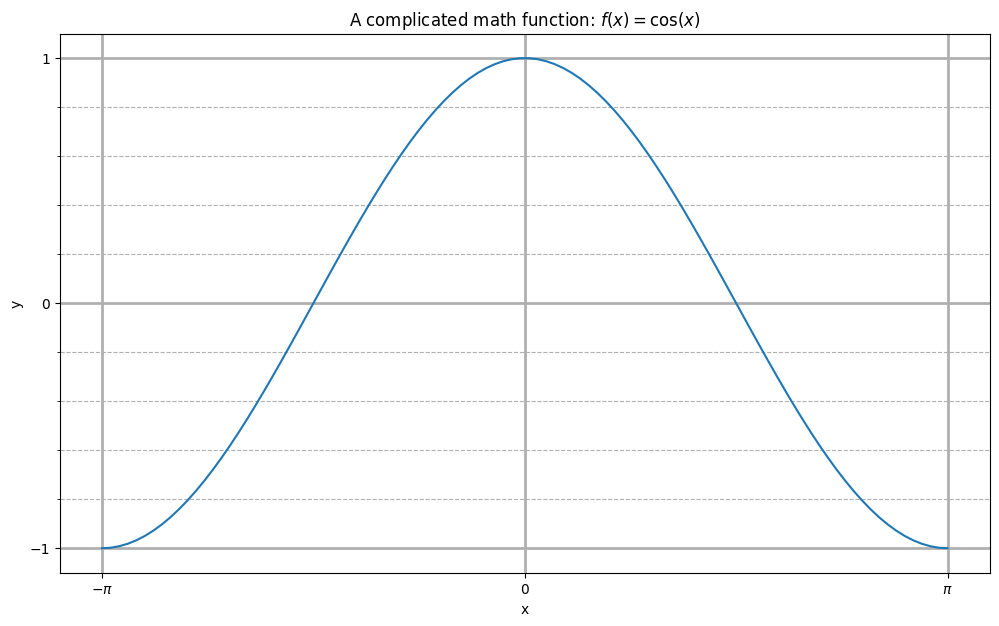

In [38]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(x, y)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'A complicated math function: $f(x) = \cos(x)$')

ax.set_xticks(np.pi * np.array([-1, 0, 1]))
ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
ax.set_yticks([-1, 0, 1])

ax.set_yticks(np.arange(-1, 1.1, 0.2), minor=True)

ax.grid(which='minor', linestyle='--')
ax.grid(which='major', linewidth=2)


### Axis Limits

(-3.0, 3.0)

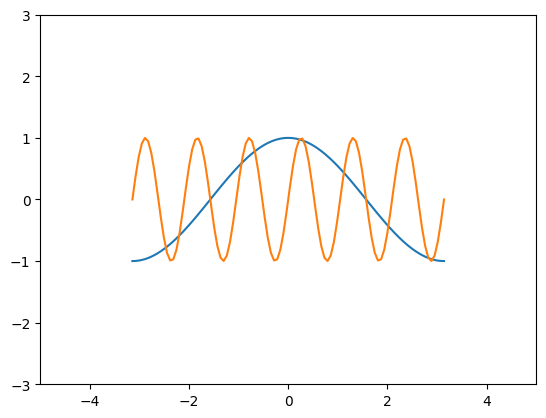

In [39]:
fig, ax = plt.subplots()
ax.plot(x, y, x, z)
ax.set_xlim(-5, 5)
ax.set_ylim(-3, 3)

### Text Annotations

Text(0, 0, 'the maximum')

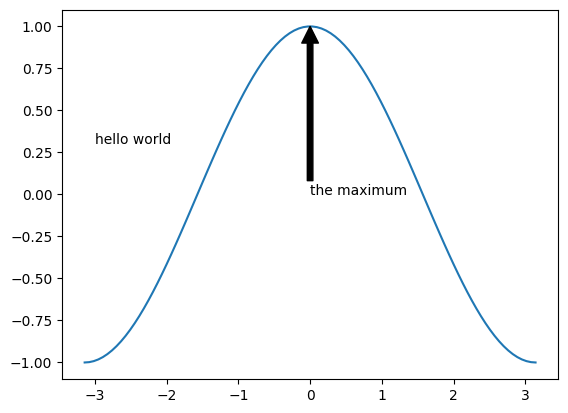

In [40]:
fig, ax = plt.subplots()
ax.plot(x, y)
ax.text(-3, 0.3, 'hello world')
ax.annotate('the maximum', xy=(0, 1),
             xytext=(0, 0), arrowprops={'facecolor': 'k'})

:::{admonition} Try it
:class: tip
Plot `y` and `z` on the same axes with different styles — say, `y` as a dashed red line and `z` as a dotted blue line with circle markers. Then customize:

- set x-ticks at `[-π, -π/2, 0, π/2, π]` using `np.pi * np.array(...)`, with LaTeX labels (`r'$-\pi$'` etc.).
- turn on a major and minor grid.
- add a title using LaTeX math, e.g. `r'$y = \cos(x)$ and $z = \sin(6x)$'`.
:::

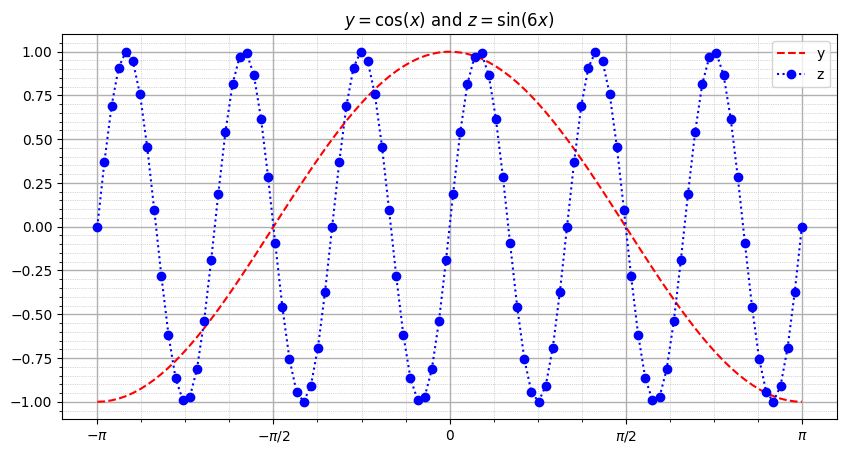

In [41]:
# --- Try it: styled lines, LaTeX ticks, grids, LaTeX title ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, color="r", linestyle="dashed", label="y")
ax.plot(x, z, color="b", linestyle="dotted", marker="o", label="z")

# x-ticks at multiples of pi, with LaTeX labels
ax.set_xticks(np.pi * np.array([-1, -0.5, 0, 0.5, 1]))
ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])

# major + minor grid
ax.minorticks_on()
ax.grid(which="major", linewidth=1)
ax.grid(which="minor", linestyle=":", linewidth=0.5)

ax.set_title(r"$y = \cos(x)$ and $z = \sin(6x)$")
ax.legend()
plt.show()

## Other 1D Plots

Not every 1D plot is a line plot. Two of the most common alternatives are **scatter plots** (each data point is its own marker — useful for showing relationships between two variables) and **bar plots** (for comparing values across discrete categories).

### Scatter Plots

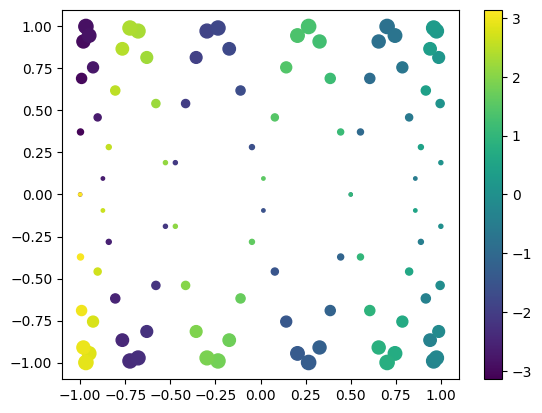

In [42]:
fig, ax = plt.subplots()

splot = ax.scatter(y, z, c=x, s=(100*z**2 + 5))
fig.colorbar(splot)

### Bar Plots

<BarContainer object of 3 artists>

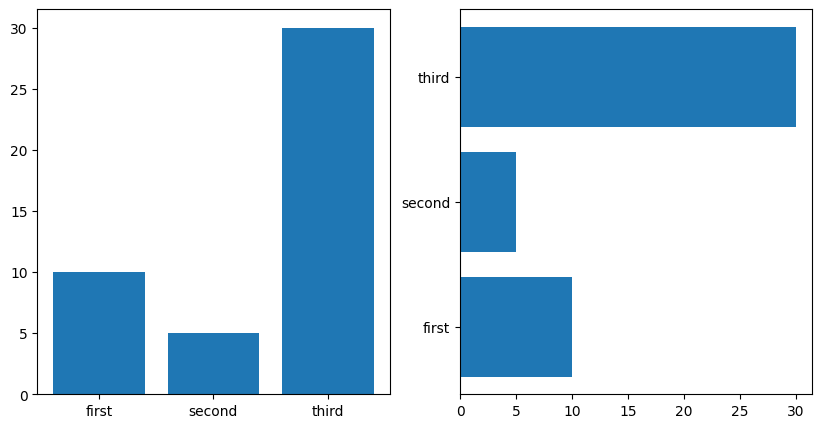

In [43]:
labels = ['first', 'second', 'third']
values = [10, 5, 30]

fig, axes = plt.subplots(figsize=(10, 5), ncols=2)
axes[0].bar(labels, values)
axes[1].barh(labels, values)

:::{admonition} Try it
:class: tip
Create a scatter plot of `y` against `z`, coloring each point by its `x` value (`c=x`), and add a colorbar. Then make a horizontal bar chart (`ax.barh`) of three labelled values of your choice.
:::

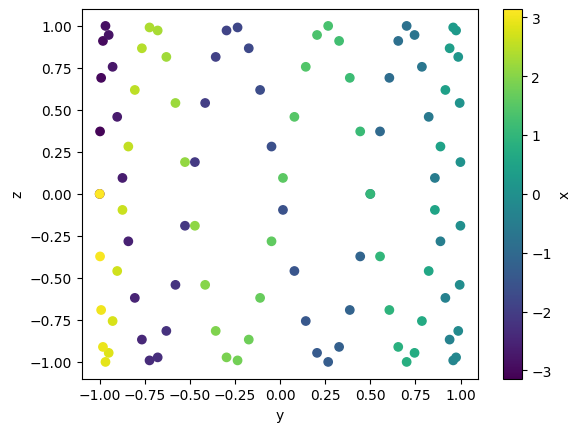

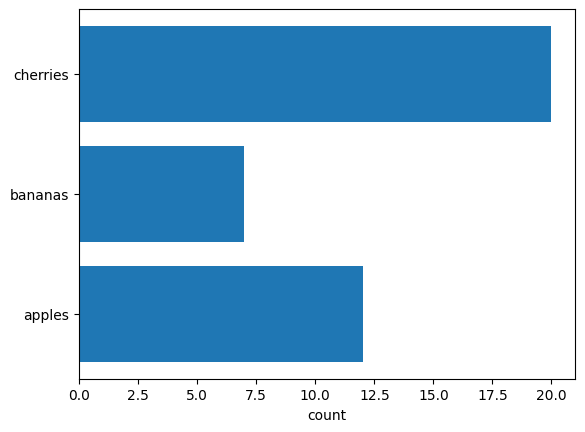

In [44]:
# --- Try it: scatter colored by x + colorbar, then a horizontal bar chart ---
fig, ax = plt.subplots()
sc = ax.scatter(y, z, c=x)
fig.colorbar(sc, label="x")
ax.set_xlabel("y"); ax.set_ylabel("z")
plt.show()

labels = ["apples", "bananas", "cherries"]
values = [12, 7, 20]
fig, ax = plt.subplots()
ax.barh(labels, values)
ax.set_xlabel("count")
plt.show()

## 2D Plotting Methods

For 2D data — gridded values like `f(x, y)` — matplotlib provides several ways to visualize. The right choice depends on whether your data is on a regular grid (use `imshow` or `pcolormesh`), whether you want isolines (`contour` / `contourf`), or whether you have vector data like flow fields (`quiver` / `streamplot`).

### imshow

`imshow` displays values directly as a colored image. It treats the input as pixel data with no coordinates — pass `origin='lower'` if you want `y=0` at the bottom (the usual convention for plots).

In [45]:
x1d = np.linspace(-2*np.pi, 2*np.pi, 100)
y1d = np.linspace(-np.pi, np.pi, 50)
xx, yy = np.meshgrid(x1d, y1d)
f = np.cos(xx) * np.sin(yy)
print(f.shape)

(50, 100)


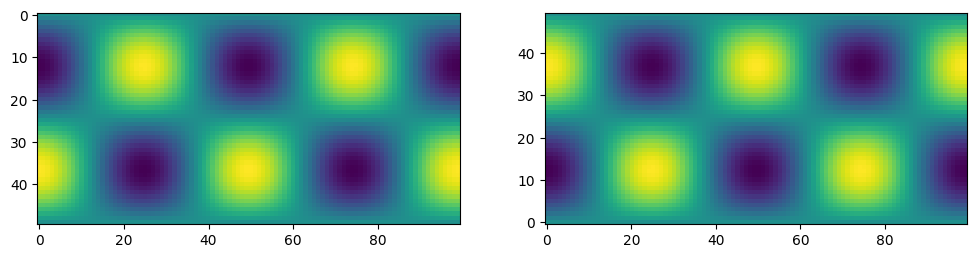

In [46]:
fig, ax = plt.subplots(figsize=(12,4), ncols=2)
ax[0].imshow(f)
ax[1].imshow(f, origin='lower')

### pcolormesh

`pcolormesh` is like `imshow` but uses explicit x/y coordinates, so you can plot on non-uniform grids and the axes show real-world units.

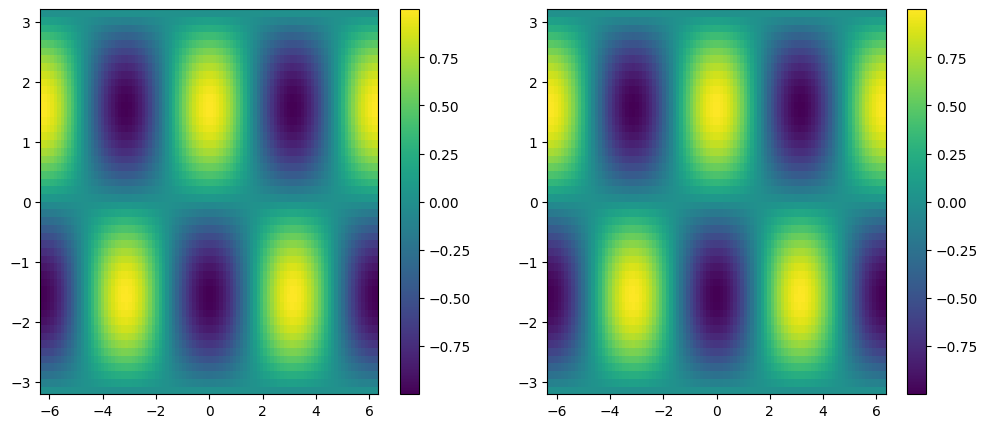

In [47]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))
pc0 = ax[0].pcolormesh(x1d, y1d, f)
pc1 = ax[1].pcolormesh(xx, yy, f)
fig.colorbar(pc0, ax=ax[0])
fig.colorbar(pc1, ax=ax[1])


When `pcolormesh` is given an `(N, M)` value array along with `(N, M)` x/y coordinates, it actually **drops the last row and column** of the values — only the first `(N-1, M-1)` are drawn. Slicing the values explicitly with `[:-1, :-1]` produces the same picture:

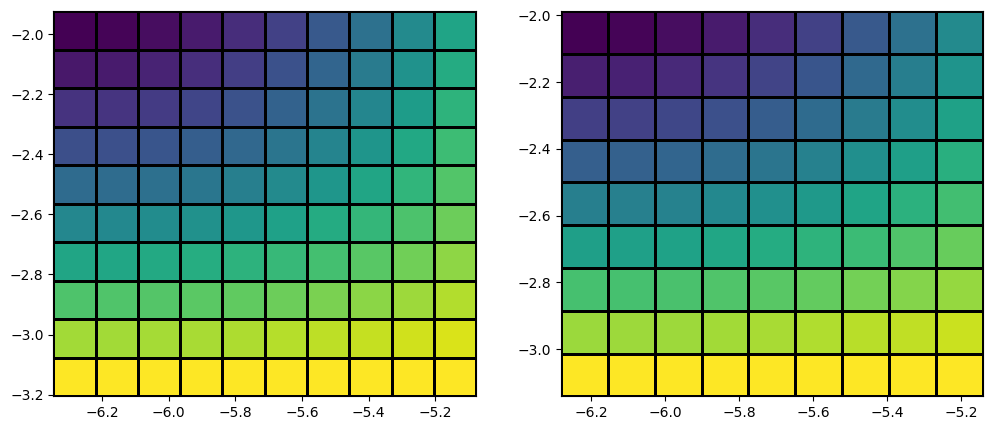

In [48]:
x_sm, y_sm, f_sm = xx[:10, :10], yy[:10, :10], f[:10, :10]

fig, ax = plt.subplots(figsize=(12,5), ncols=2)

ax[0].pcolormesh(x_sm, y_sm, f_sm, edgecolors='k')

ax[1].pcolormesh(x_sm, y_sm, f_sm[:-1, :-1], edgecolors='k')


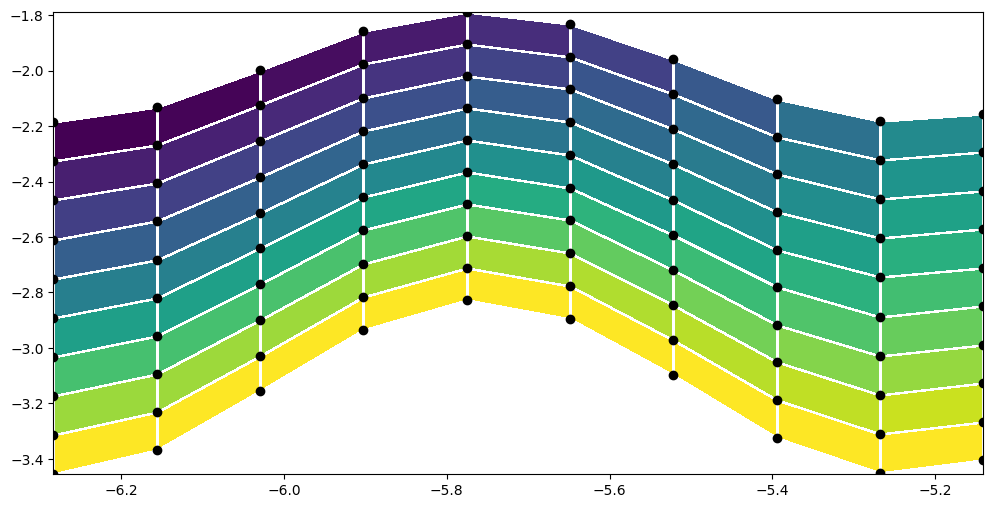

In [49]:
y_distorted = y_sm*(1 + 0.1*np.cos(6*x_sm))

plt.figure(figsize=(12,6))
plt.pcolormesh(x_sm, y_distorted, f_sm[:-1, :-1], edgecolors='w')
plt.scatter(x_sm, y_distorted, c='k')

### contour / contourf

`contour` draws isolines (lines of constant value); `contourf` fills the regions between them.

Unlike `pcolormesh`, `contour` works equally well with 1D coordinate arrays or with 2D meshgrid arrays — both produce the same picture:

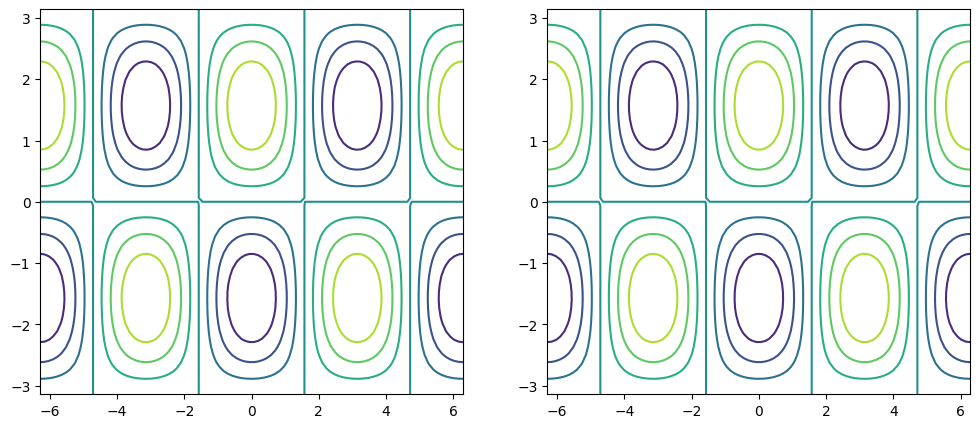

In [50]:
fig, ax = plt.subplots(figsize=(12, 5), ncols=2)

ax[0].contour(x1d, y1d, f)
ax[1].contour(xx, yy, f)

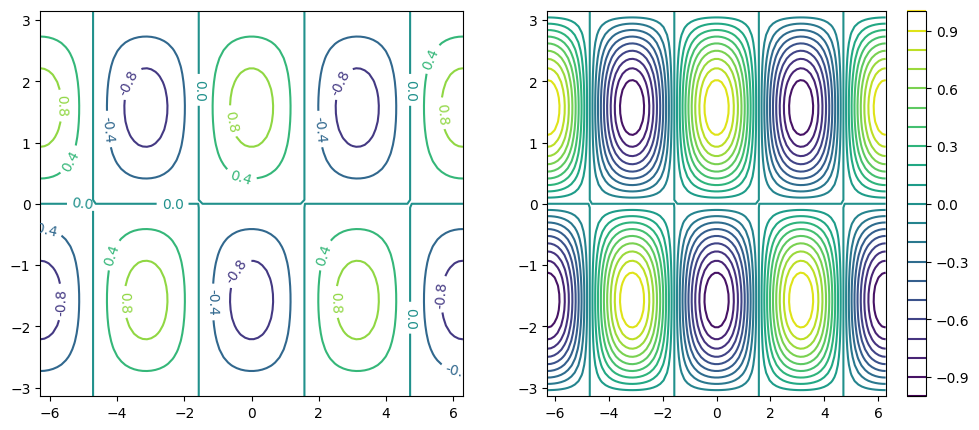

In [51]:
fig, ax = plt.subplots(figsize=(12, 5), ncols=2)

c0 = ax[0].contour(xx, yy, f, 5)
c1 = ax[1].contour(xx, yy, f, 20)

plt.clabel(c0, fmt='%2.1f')
plt.colorbar(c1, ax=ax[1])

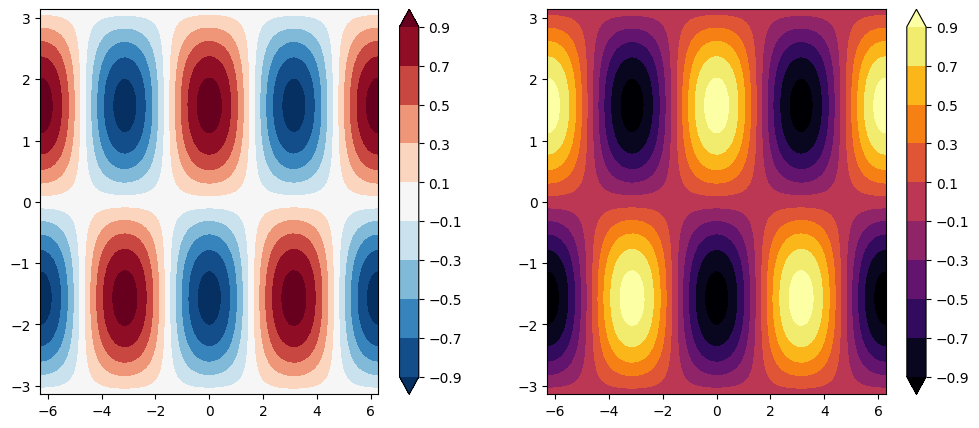

In [52]:
fig, ax = plt.subplots(figsize=(12, 5), ncols=2)

clevels = np.arange(-1, 1, 0.2) + 0.1

cf0 = ax[0].contourf(xx, yy, f, clevels, cmap='RdBu_r', extend='both')
cf1 = ax[1].contourf(xx, yy, f, clevels, cmap='inferno', extend='both')

fig.colorbar(cf0, ax=ax[0])
fig.colorbar(cf1, ax=ax[1])

### quiver

`quiver` plots a vector field as arrows — useful for flow data like winds, ocean currents, or gradients.

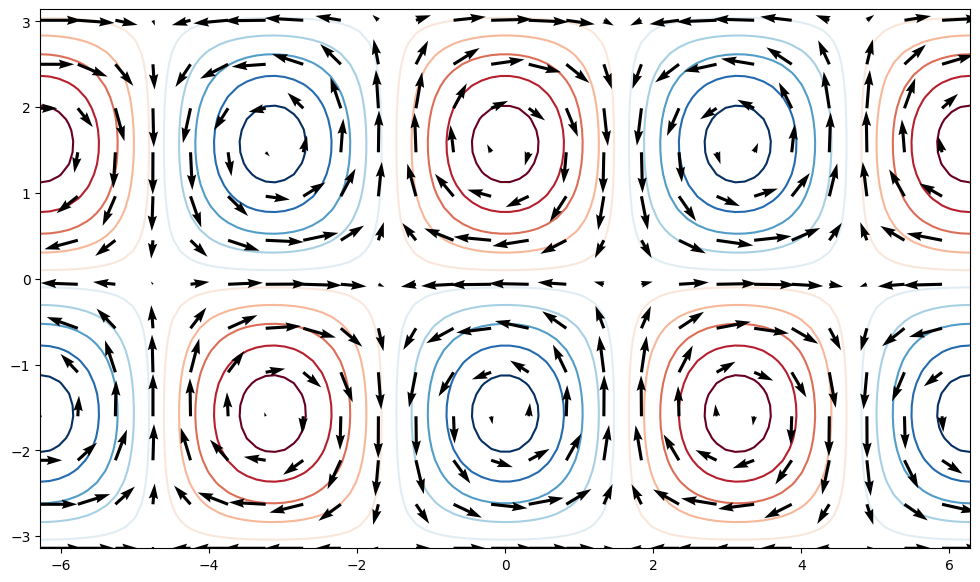

In [53]:
u = -np.cos(xx) * np.cos(yy)
v = -np.sin(xx) * np.sin(yy)

fig, ax = plt.subplots(figsize=(12, 7))
ax.contour(xx, yy, f, clevels, cmap='RdBu_r', extend='both', zorder=0)
ax.quiver(xx[::4, ::4], yy[::4, ::4],
           u[::4, ::4], v[::4, ::4], zorder=1)

### streamplot

`streamplot` traces flow lines through a vector field — useful for visualizing turbulent flow or current patterns.

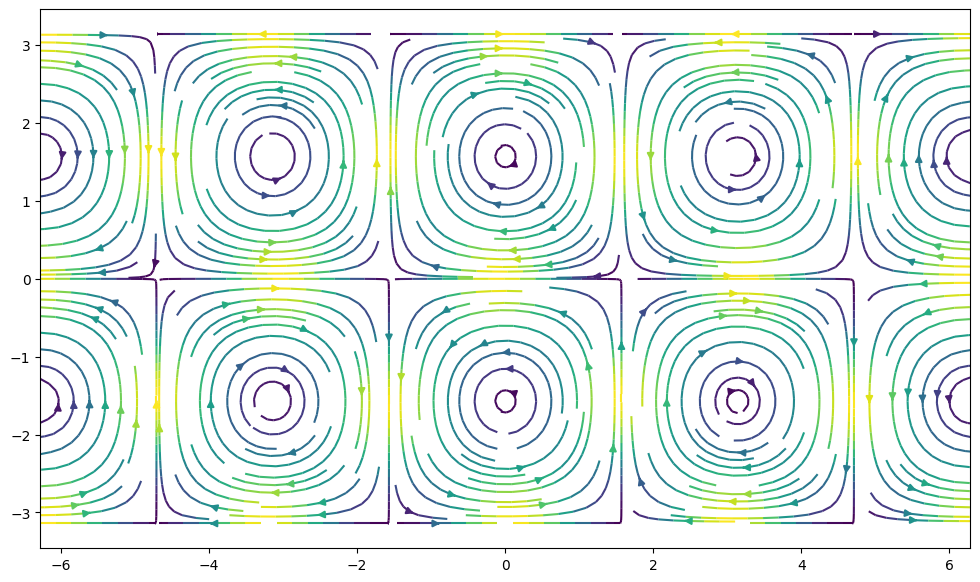

In [54]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.streamplot(xx, yy, u, v, density=2, color=(u**2 + v**2))

:::{admonition} Try it
:class: tip
Compute a 2D Gaussian: `f = np.exp(-(xx**2 + yy**2))` on a meshgrid. Make a figure with **three subplots** showing it via `pcolormesh`, `contourf`, and `imshow(..., origin='lower')`. Give each subplot its own colorbar.
:::

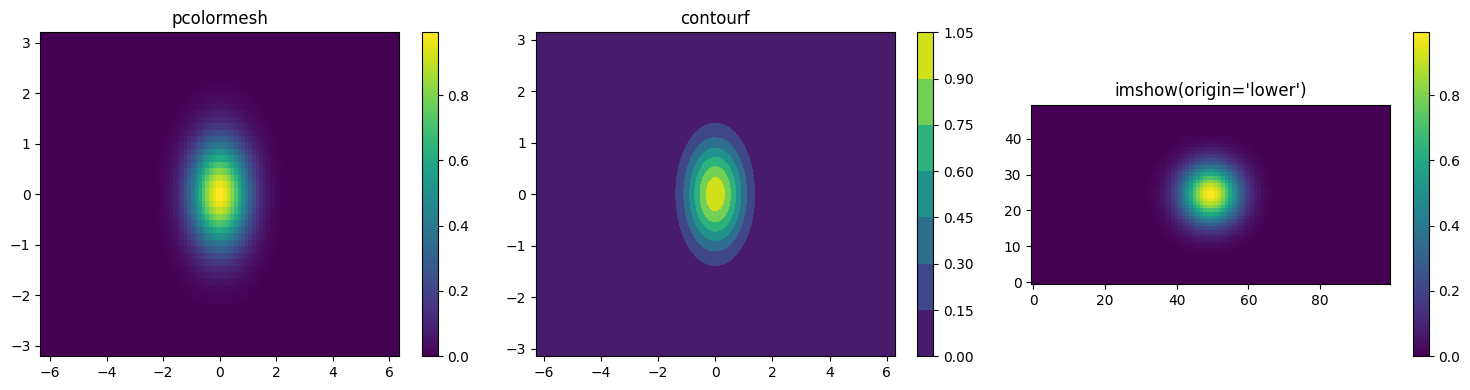

In [55]:
# --- Try it: 2D Gaussian shown 3 ways, each with its own colorbar ---
f_gauss = np.exp(-(xx**2 + yy**2))        # reuse the meshgrid from above

fig, ax = plt.subplots(ncols=3, figsize=(15, 4))

pc = ax[0].pcolormesh(x1d, y1d, f_gauss)
ax[0].set_title("pcolormesh"); fig.colorbar(pc, ax=ax[0])

cf = ax[1].contourf(x1d, y1d, f_gauss)
ax[1].set_title("contourf"); fig.colorbar(cf, ax=ax[1])

im = ax[2].imshow(f_gauss, origin="lower")
ax[2].set_title("imshow(origin='lower')"); fig.colorbar(im, ax=ax[2])

plt.tight_layout()
plt.show()

## Recap

You've now seen how Matplotlib is put together and the main tools for using it:

- **The Figure / Axes model** — a Figure is the canvas; each Axes is one plot, created with `plt.subplots()` and drawn into explicitly.
- **Line plots and styling** — colors, line styles, markers, labels, ticks, gridlines, axis limits, and text annotations.
- **Other 1-D plots** — scatter and bar charts.
- **2-D fields** — `imshow`, `pcolormesh`, `contour`/`contourf` for scalar fields, and `quiver`/`streamplot` for vector fields — the building blocks of climate maps.

With NumPy and Matplotlib in hand, you're ready for **pandas**, where these arrays gain labels and become tables you can slice, group, and analyze.